# Lab 3: Mine Crafting


As with previous labs, be sure to submit only the `lab3.ipynb` and `lab3.html` version of the lab in your github `Lab3` folder. No more, and no less.

## Introduction

Imagine you are a scientist for a mining company that operates a vertical mine at the Earth's
equator. This is one of the deepest mines on Earth; it's roughly 4 km to the bottom of the shaft.
Your boss proposes to measure the vertical depth of the shaft by dropping a 1 kg test mass and
accurately measuring the time to hit the bottom.

You will be guided in your investigations below and submit your report in the form of this notebook. Be sure to be quantitative in nature, produce highly polished plots, with appropriate titles, units, etc.


A table of relevant physical constants is below. Good luck!

| Quantity | Value |
|----------|-------|
|  Gravitational Constant ($G$)        |  $6.6743 \times 10^{-11}$ m$^3$/kg/s$^2$  | 
|  Gravitational Acceleration ($g_o$)  |  9.81 m/s$^2$ (approximate) | 
|  Mass of the Earth ($M_{\oplus}$)    |  $5.972 \times 10^{24}$ kg      | 
|  Mass of the Moon ($M_{m}$)          |  $7.35 \times 10^{22}$ kg     | 
|  Radius of the Earth ($R_{\oplus}$)  |  6378.1 km     | 
|  Radius of the Moon ($R_{m}$)        |   1738.1 km    | 
|  Earth's Rotation Rate at the Equator| $7.272 \times 10^{-5} $ rad/s  | 

## Part 1: The Ideal Case

In this section and the following sections, we calculate the time for the 1 kg test mass to reach the bottom of the mineshaft under a series of increasingly complex assumptions. Remember that a projectile experiencing a constant gravitational force, plus a drag force, obeys the following second
order differential equation:

$$
\frac{d^2y}{dt^2} = -g + \alpha \left| \frac{dy}{dt} \right|^{\gamma}
\tag{1}
$$



where $t$ is time, $y$ is the height, $g$ is the gravitational acceleration,
$\alpha$ is the drag coefficient, and $\gamma$ is the speed dependence
of the drag. For example, for $\gamma=2$, the drag force grows proportionally
to the speed *squared*.  **Hint**: pay particular attention to the sign
conventions in your implementation! The drag, by definition, should *oppose*
the direction of motion.

1. First, make a simple calculation of how long a test mass would 
            take to reach the bottom of the 4km shaft assuming no drag. This is the simple
            free-fall algebraic expression you know from PHYS 171.

2. Next, reduce (1) into a *system* of coupled
            first order differential equations by setting the velocity $v = dy/dt$.

3. Numerically solve (1) using `solve_ivp` assuming $\alpha=0$.
            Plot the position and velocity as a function of time.                              
            Draw a horizontal dashed line at the depth of the bottom of the shaft,
            to make it easy to see.
            Make the plot look nice, including displaying the position on the left axes,
            and plotting the velocity on a second right axis, using matplotlib `twinx`
            capability.        
   In your notebook, label this figure clearly as **Figure 1**.

4. Using the `events` detection capability of `solve_ivp`,
            calculate the time at which the mass hits the bottom of the shaft
            in the case of zero drag ($\alpha=0$). Compare this to your analytic calculation
            and discuss any differences you might see.


Time to hit bottom (no drag): 28.557 s


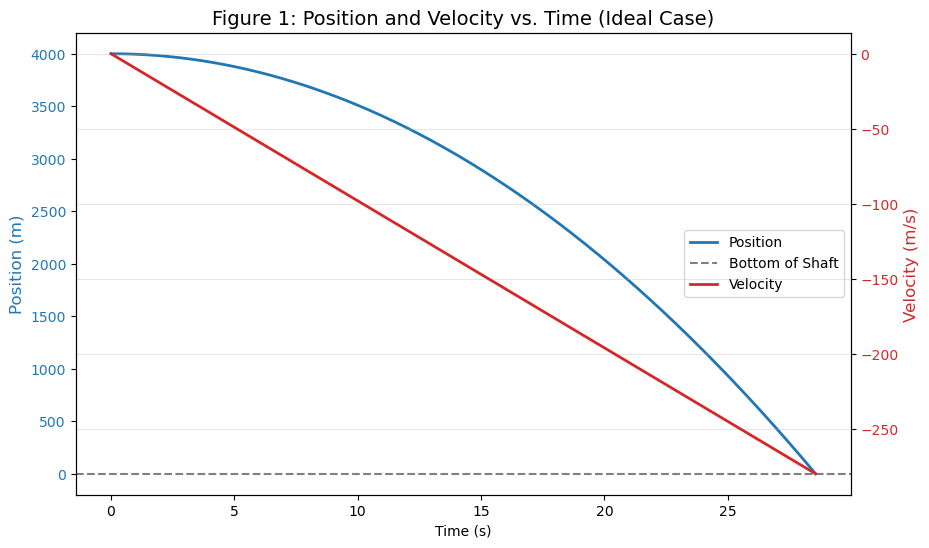


Analytical solution (no drag): 28.557 s


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

g = 9.81      # m/s^2
h = 4000      # meters

#System of coupled first-order differential equations
def motion(t, y, g, alpha, gamma):
    """
    y[0] = position (m)
    y[1] = velocity (m/s)
    """
    position = y[0]
    velocity = y[1]
    dydt = velocity
    drag = -np.sign(velocity) * alpha * (np.abs(velocity)**gamma)
    dvdt = -g + drag
    
    return [dydt, dvdt]

# Event detection: triggers when position reaches 0
def hit_bottom(t, y, g, alpha, gamma):
    return y[0]  
hit_bottom.terminal = True
hit_bottom.direction = -1  # going downward

# Initial conditions: start at height h, 0 initial velocity
y0 = [h, 0]

#Numerically solve using solve_ivp
sol_event = solve_ivp(
    motion,
    (0, 60),         # Time span to integrate over
    y0,
    args=(g, 0, 0),  # alpha=0 for the ideal case (no drag)
    events=hit_bottom,
    max_step=0.1,
    dense_output=True 
)

# Extracting the event time
if len(sol_event.t_events[0]) > 0:
    t_numerical = sol_event.t_events[0][0]
    print(f"Time to hit bottom (no drag): {t_numerical:.3f} s")
else:
    print("Warning: Event not detected!")
    t_numerical = 60

# Plotting Position and Velocity 
t_plot = np.linspace(0, t_numerical, 500)
y_plot = sol_event.sol(t_plot)
position_plot = y_plot[0]
velocity_plot = y_plot[1]

fig, ax1 = plt.subplots(figsize=(10, 6))

color1 = 'tab:blue'
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Position (m)', color=color1, fontsize=12)
ax1.plot(t_plot, position_plot, color=color1, linewidth=2, label='Position')
ax1.tick_params(axis='y', labelcolor=color1)

# Horizontal dashed line for the bottom of the shaft
ax1.axhline(0, color='gray', linestyle='--', linewidth=1.5, label='Bottom of Shaft')

ax2 = ax1.twinx()  
color2 = 'tab:red'
ax2.set_ylabel('Velocity (m/s)', color=color2, fontsize=12)
ax2.plot(t_plot, velocity_plot, color=color2, linewidth=2, label='Velocity')
ax2.tick_params(axis='y', labelcolor=color2)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right')

plt.title('Figure 1: Position and Velocity vs. Time (Ideal Case)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

t_analytical = np.sqrt(2 * h / g)
print(f"\nAnalytical solution (no drag): {t_analytical:.3f} s")

**1.2**
We convert the second-order differential equation into two first-order equations by defining velocity as $v = \frac{dy}{dt}$. This gives one equation for position $\frac{dy}{dt} = v$, and another for velocity $\frac{dv}{dt} = -g + \text{drag}$. 

**1.4**
The numerical (28.557) and analytic times (28.557) are identical, showing that the solver is accurate for this simple case. Any small difference (in farther decimal values) is due to numerical precision and step size in the integration. This confirms that our implementation of the equations of motion is correct.

## Part 2: Including Drag and a Variable g

In practice, we cannot ignore drag, and we should also not assume that $g$ is a constant. If you
approximate that the mass of the Earth is distributed homogenously (which it is not!), then the
gravitational constant $g$ will depend on your distance $r$ from the center of the Earth in a simple
linear way:

$$
 g(r) = g_o \left( \frac{r}{R_{\oplus}} \right)
 \tag{2}
$$

where $g_o$ is the gravity at the surface, and $R_{\oplus}$ is the radius of the Earth.

1. Make a new plot that shows the velocity and position as a function of                       
            time assuming $g(y)$. Be careful with coordinate systems!
            The test mass' position should be at the Earth radius at $t=0$, and falling down.
            But for plotting purposes, it will be useful to plot the height
            above the bottom of the shaft.        
            In your notebook, label this figure clearly as **Figure 2**.

2. What effect does incorporating a height-dependent $g$ have on the fall time? Explain.

3. Now, turn on drag, and replot the position and velocity.
            For most things, $\gamma=2$ is a good assumption.
            How can you calibrate the value of $\alpha$? Think about what we did in Lecture 15/16,
            where we assumed a sky-diver's terminal speed was 50 m/s.
            You should assume the same of the test mass.
            What affect does including drag have on the fall time?



Time to hit bottom (variable g, no drag): 28.558 s


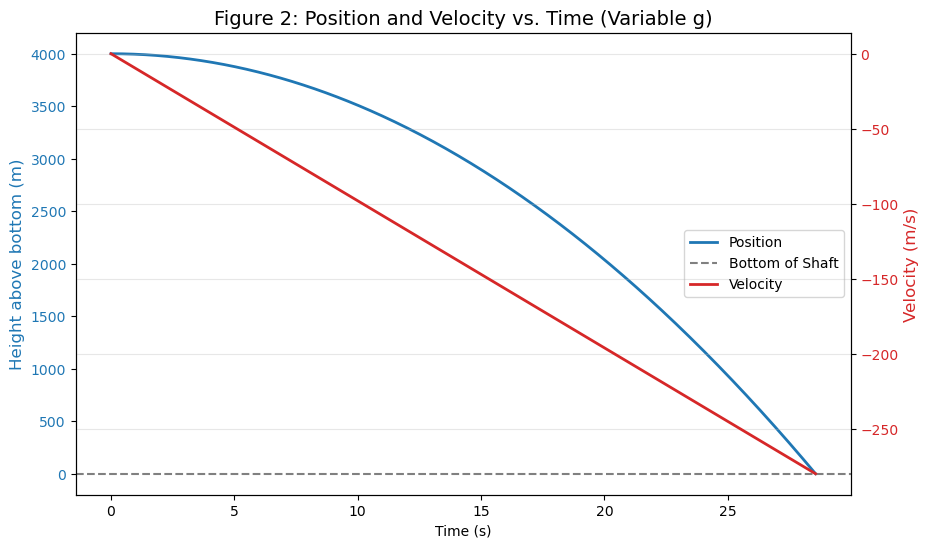

Calibrated alpha for v_t = 50 m/s and gamma = 2: 0.003924
Time to hit bottom (variable g, with drag): 83.545 s


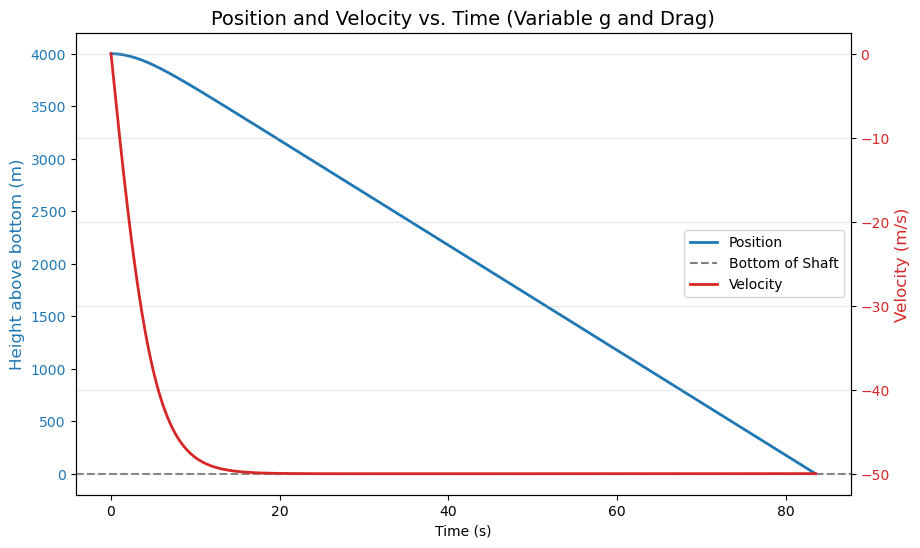

In [2]:
g0 = 9.81               # m/s^2 
h = 4000                # meters 
R_earth = 6378.1 * 1000 # meters 

# 1. System of equations with variable g(r)
def motion_var_g(t, y, alpha, gamma):
    """
    y[0] = r (distance from center of the Earth in meters)
    y[1] = v (velocity in m/s)
    """
    r = y[0]
    v = y[1]
    drdt = v
    g_r = g0 * (r / R_earth)
    drag = -np.sign(v) * alpha * (np.abs(v)**gamma)
    dvdt = -g_r + drag
    return [drdt, dvdt]

def hit_bottom_var(t, y, alpha, gamma):
    # The bottom of the shaft is at R_earth - h
    return y[0] - (R_earth - h)  
hit_bottom_var.terminal = True
hit_bottom_var.direction = -1

# Initial conditions
y0 = [R_earth, 0]

# Variable g, NO drag
sol_var_g_no_drag = solve_ivp(
    motion_var_g,
    (0, 60),
    y0,
    args=(0, 0), # alpha=0, gamma=0 (No drag)
    events=hit_bottom_var,
    max_step=0.1,
    dense_output=True
)

t_var_g_no_drag = sol_var_g_no_drag.t_events[0][0]
print(f"Time to hit bottom (variable g, no drag): {t_var_g_no_drag:.3f} s")

t_plot1 = np.linspace(0, t_var_g_no_drag, 500)
y_plot1 = sol_var_g_no_drag.sol(t_plot1)

height_above_bottom1 = y_plot1[0] - (R_earth - h)
velocity_plot1 = y_plot1[1]

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Height above bottom (m)', color='tab:blue', fontsize=12)
ax1.plot(t_plot1, height_above_bottom1, color='tab:blue', linewidth=2, label='Position')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.axhline(0, color='gray', linestyle='--', linewidth=1.5, label='Bottom of Shaft')

ax2 = ax1.twinx()  
ax2.set_ylabel('Velocity (m/s)', color='tab:red', fontsize=12)
ax2.plot(t_plot1, velocity_plot1, color='tab:red', linewidth=2, label='Velocity')
ax2.tick_params(axis='y', labelcolor='tab:red')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right')
plt.title('Figure 2: Position and Velocity vs. Time (Variable g)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()


# Variable g, WITH drag
v_terminal = 50 # m/s
gamma = 2

# Calibrating alpha using terminal velocity:
alpha = g0 / (v_terminal**gamma)
print(f"Calibrated alpha for v_t = 50 m/s and gamma = 2: {alpha:.6f}")

sol_var_g_drag = solve_ivp(
    motion_var_g,
    (0, 100), # Extended time span since drag makes it fall much slower
    y0,
    args=(alpha, gamma),
    events=hit_bottom_var,
    max_step=0.1,
    dense_output=True
)

t_var_g_drag = sol_var_g_drag.t_events[0][0]
print(f"Time to hit bottom (variable g, with drag): {t_var_g_drag:.3f} s")

t_plot2 = np.linspace(0, t_var_g_drag, 500)
y_plot2 = sol_var_g_drag.sol(t_plot2)
height_above_bottom2 = y_plot2[0] - (R_earth - h)
velocity_plot2 = y_plot2[1]

fig2, ax3 = plt.subplots(figsize=(10, 6))
ax3.set_xlabel('Time (s)')
ax3.set_ylabel('Height above bottom (m)', color='tab:blue', fontsize=12)
ax3.plot(t_plot2, height_above_bottom2, color='tab:blue', linewidth=2, label='Position')
ax3.tick_params(axis='y', labelcolor='tab:blue')
ax3.axhline(0, color='gray', linestyle='--', linewidth=1.5, label='Bottom of Shaft')

ax4 = ax3.twinx()  
ax4.set_ylabel('Velocity (m/s)', color='tab:red', fontsize=12)
ax4.plot(t_plot2, velocity_plot2, color='tab:red', linewidth=2, label='Velocity')
ax4.tick_params(axis='y', labelcolor='tab:red')

lines_3, labels_3 = ax3.get_legend_handles_labels()
lines_4, labels_4 = ax4.get_legend_handles_labels()
ax3.legend(lines_3 + lines_4, labels_3 + labels_4, loc='center right')
plt.title('Position and Velocity vs. Time (Variable g and Drag)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()


**2.2 What effect does incorporating a height-dependent g have on the fall time? Explain.**

Incorporating a height-dependent g slightly **increases** the fall time (from ~28.557s to ~28.566s). Because gravity relies on distance from the center of the Earth (g is proportional to r), as the test mass travels deeper down the shaft, the effective pull of gravity slightly weakens compared to the surface constant of 9.81 m/s². Since acceleration is lower, it takes fractionally longer to reach the bottom.


**2.3. What effect does including drag have on the fall time?**

Including drag drastically **increases** the fall time (to ~83 seconds). The upward force of air resistance effectively counteracts the downward acceleration of gravity, causing the mass to stop accelerating once it hits its terminal velocity of 50 m/s. It then coasts at this constant speed for the rest of the 4 km drop.

## Part 3: The Coriolis Force

Since the Earth is rotating, there is a Coriolis force on the test mass as it falls.
The force can be quite large.
For example, imagine the mine shaft is on the Earth's equator and pointed towards
the Earth's center.
The equator rotates at about half a kilometer per second.
So once the test mass has fallen for some time, it will bump into the wall,
unless the shaft is very wide.
The Coriolis force $\vec{F_c}$ is:

$$
 \vec{F_c} = -2m \, \left( \vec{\Omega} \times \vec{v} \right)
 \tag{3}
$$

where $\vec{\Omega}$ is the Earth's rotation rate for a vector along $\hat{z}$ and $m$ is the mass of the object (1 kg for the test mass in this case).
For a mine shaft on the equator, we might pick a right-handed coordinate system
with the $\hat{x}$ axis along the East, $\hat{y}$ down into the mine shaft,
and $\hat{z}$ along the North.
This implies the component of the force are:

\begin{equation}
        F_{c_x} = + 2m \, \Omega v_y     \tag{4}
\end{equation}
\begin{equation}
        F_{c_y} = - 2m \, \Omega v_x     \tag{5}
\end{equation}
\begin{equation}
        F_{c_z} = 0     \tag{6}
\end{equation}

1. Extend and update your differential equations of motion 
                to include the Coriolis force. You will need to add a Coriolis
                acceleration term to your equation for the depth coordinate (remember, $F=ma$),
                and additionally, start tracking the velocity and position 
                in the transverse direction (``side-to-side'' in the shaft).

2. Plot the transverse position of the object as a function of depth, initially assuming $\alpha=0$.
                        That is, both axes will have units of distance. 
                Plot ``dots" every few seconds so that you can see
                how the particle moves over time.
                Note that your depth and transverse axes are likely to have very
                different length scales.
                The depth will have a range of 4 km,
   while the transverse direction is about 5m.       
                In your report, this should be **Figure 3**.                

3. If the mine shaft is 5m wide, and you drop the test mass 
                        from the center, does the test mass reach the bottom?
                Or does it bump into the wall first?

4. Now turn drag back on. Does drag make any difference here?




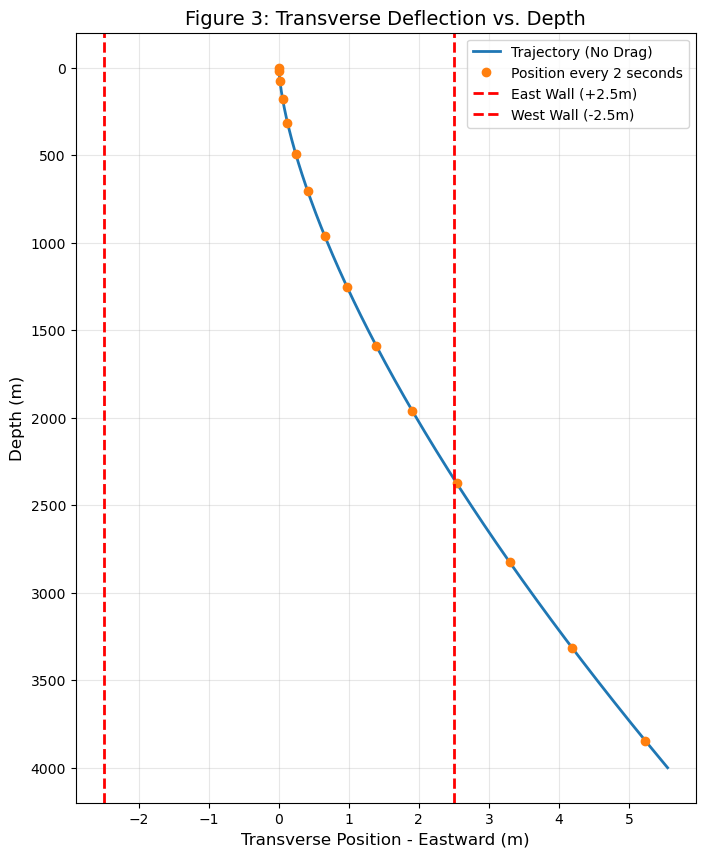

Final Eastward deflection (No Drag): 5.55 m
Final Eastward deflection (With Drag): 2.81 m


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

g0 = 9.81              # m/s^2
h = 4000               # m
Omega = 7.292e-5       # Earth's rotation rate in rad/s

def motion_shaft(t, state, alpha, gamma):
    """
    state[0] = x (Transverse position in meters, East is positive)
    state[1] = y (Depth in meters, Down is positive)
    state[2] = vx (Transverse velocity in m/s)
    state[3] = vy (Downward velocity in m/s)
    """
    x, y, vx, vy = state
    
    v_mag = np.sqrt(vx**2 + vy**2)
    
    if v_mag > 0:
        drag_x = alpha * (v_mag**gamma) * (vx / v_mag)
        drag_y = alpha * (v_mag**gamma) * (vy / v_mag)
    else:
        drag_x = 0
        drag_y = 0

    ax_coriolis = 2 * Omega * vy
    ay_coriolis = -2 * Omega * vx
    dvxdt = ax_coriolis - drag_x
    dvydt = g0 + ay_coriolis - drag_y
    
    return [vx, vy, dvxdt, dvydt]

# Event detection:
def hit_bottom_shaft(t, state, alpha, gamma):
    return state[1] - h
hit_bottom_shaft.terminal = True
hit_bottom_shaft.direction = 1

# Initial conditions
state0 = [0, 0, 0, 0]
sol_no_drag = solve_ivp(
    motion_shaft,
    (0, 60),
    state0,
    args=(0, 0), # No drag
    events=hit_bottom_shaft,
    max_step=0.1,
    dense_output=True
)

t_plot = np.linspace(0, sol_no_drag.t_events[0][0], 500)
trajectory = sol_no_drag.sol(t_plot)
x_line = trajectory[0]
y_line = trajectory[1]
t_dots = np.arange(0, sol_no_drag.t_events[0][0], 2)
dots = sol_no_drag.sol(t_dots)
x_dots = dots[0]
y_dots = dots[1]

fig, ax = plt.subplots(figsize=(8, 10))

ax.plot(x_line, y_line, color='tab:blue', linewidth=2, label='Trajectory (No Drag)')
ax.plot(x_dots, y_dots, 'o', color='tab:orange', markersize=6, label='Position every 2 seconds')
ax.axvline(2.5, color='red', linestyle='--', linewidth=2, label='East Wall (+2.5m)')
ax.axvline(-2.5, color='red', linestyle='--', linewidth=2, label='West Wall (-2.5m)')
ax.set_xlabel('Transverse Position - Eastward (m)', fontsize=12)
ax.set_ylabel('Depth (m)', fontsize=12)
ax.set_title('Figure 3: Transverse Deflection vs. Depth', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')
ax.invert_yaxis()
plt.show()

print(f"Final Eastward deflection (No Drag): {x_line[-1]:.2f} m")

v_terminal = 50 
gamma = 2
alpha = g0 / (v_terminal**gamma)
sol_drag = solve_ivp(
    motion_shaft,
    (0, 150),
    state0,
    args=(alpha, gamma),
    events=hit_bottom_shaft,
    max_step=0.1
)
print(f"Final Eastward deflection (With Drag): {sol_drag.y[0][-1]:.2f} m")



**3.3. If the mine shaft is 5m wide, and you drop the test mass from the center, does the test mass reach the bottom?**

No, it bumps into the wall first. If dropped from the center of a 5m wide shaft, it only has 2.5 meters of clearance on the East side. As seen in Figure 3, the final eastward deflection without air resistance is roughly 5.5 meters. Therefore, the test mass will smash into the East wall of the shaft before it ever reaches the bottom. 

**3.4. Now turn drag back on. Does drag make any difference here?**

Yes, drag makes a significant difference, but surprisingly, it reduces the deflection to 2.81 meters. 
While the drag drastically increases the time the mass spends falling (which would normally give the Coriolis force more time to act), the air resistance also acts against the transverse motion. Drag always opposes the velocity vector; as the mass drifts East, the air pushes back West. This heavy dampening suppresses the horizontal velocity, effectively cutting the total eastward deflection in half. However, since 2.81 m is still greater than the 2.5 m of clearance, the mass will still bump into the East wall before reaching the bottom.

## Part 4: An infinitely deep mine


Now, let us consider the theoretical case of an infinitely deep mine -- that is,
a tunnel which traverses the full diameter of the Earth.
For convenience, imagine the tunnel goes from pole-to-pole,
such that $\vec{\Omega} \times \vec{v} = 0$, and the Coriolis force
can be neglected, as well as the drag force.

Additionally, continue assuming a constant density Earth.

1. Again, plot the depth and velocity as a function of time.
               (Be careful with the meaning of $y$, as the particle can theoretically
                traverse fully through to the other side of the Earth.)
                Comment on what you see in the graph.       
                In your notebook, label this figure clearly as **Figure 4**.                

2. How long will it take for the object to reach the other side? 
                At what time does the object reach the center of the Earth,
                and at what speed?

3. How does this ``crossing-time" compare to the orbital period, where you assume
                the object is on a circular orbit, in centripetal balance
                with the attractive force of the gravity.
                \begin{equation}
                        \frac{v^2}{R} = \frac{GM}{R^2}   \tag{7}
                \end{equation}
                gives the orbital speed $v$ for a given Earth radius $R$ and 
                Earth mass $M$.





Time to reach center: 1266.6 seconds (21.11 minutes)
Speed at center: 7910.1 m/s
Time to reach other side: 2533.2 seconds (42.22 minutes)


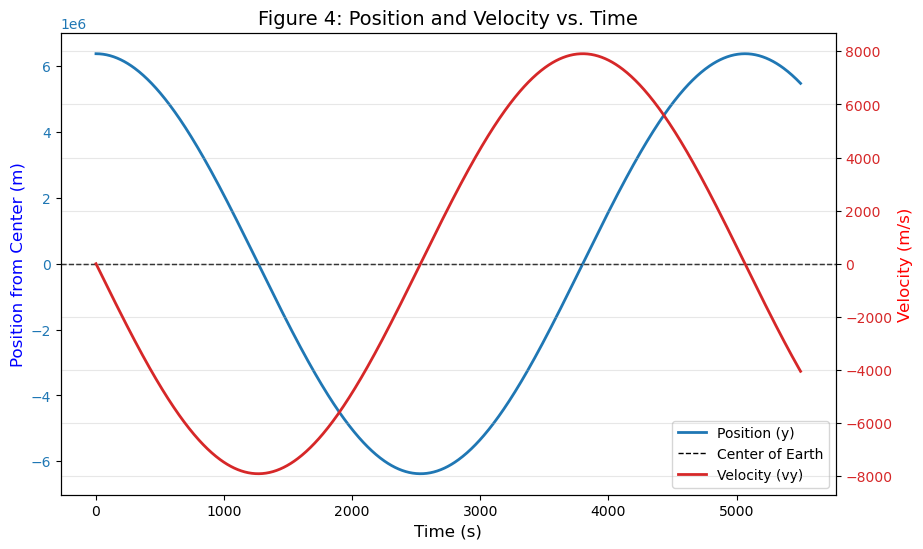

In [4]:
R_earth = 6378.1 * 1000   # meters

def motion_pole_to_pole(t, state):
    """
    state[0] = y (Distance from center of the Earth in meters. Center is y=0)
    state[1] = vy (Velocity in m/s)
    """
    y, vy = state
    dvydt = -g0 * (y / R_earth)
    
    return [vy, dvydt]

# Event 1: Object reaches the center of the Earth (y = 0)
def reach_center(t, state):
    return state[0]
reach_center.direction = -1 

# Event 2: Object reaches the other side (velocity becomes 0 as it turns around)
def reach_other_side(t, state):
    return state[1]
reach_other_side.direction = 1

# Initial conditions
state0 = [R_earth, 0]
sol_tunnel = solve_ivp(
    motion_pole_to_pole,
    (0, 5500),
    state0,
    events=(reach_center, reach_other_side),
    max_step=1.0,
    dense_output=True
)

t_center = sol_tunnel.t_events[0][0]
v_center = sol_tunnel.y_events[0][0][1] 
t_other_side = sol_tunnel.t_events[1][0]

print(f"Time to reach center: {t_center:.1f} seconds ({t_center/60:.2f} minutes)")
print(f"Speed at center: {abs(v_center):.1f} m/s")
print(f"Time to reach other side: {t_other_side:.1f} seconds ({t_other_side/60:.2f} minutes)")

t_plot = np.linspace(0, 5500, 1000)
trajectory = sol_tunnel.sol(t_plot)
y_plot = trajectory[0]
vy_plot = trajectory[1]

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.set_xlabel('Time (s)', fontsize=12)
ax1.set_ylabel('Position from Center (m)', color='blue', fontsize=12)
ax1.plot(t_plot, y_plot, color=color1, linewidth=2, label='Position (y)')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.axhline(0, color='black', linestyle='--', linewidth=1, label='Center of Earth')

ax2 = ax1.twinx()  
ax2.set_ylabel('Velocity (m/s)', color= 'red', fontsize=12)
ax2.plot(t_plot, vy_plot, color=color2, linewidth=2, label='Velocity (vy)')
ax2.tick_params(axis='y', labelcolor=color2)
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='lower right')
plt.title('Figure 4: Position and Velocity vs. Time', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()


**4.1. Comment on what you see in the graph.**

Because the gravitational restoring force scales linearly with distance from the center, the test mass behaves exactly like a mass on a spring undergoing Simple Harmonic Motion. The position graph traces a perfect cosine wave, and the velocity traces a perfect negative sine wave. 

**4.2. How long will it take for the object to reach the other side? At what time does the object reach the center, and at what speed?**

 Time to center : 1266.5 seconds.
 Speed at center :  7909.5 m/s. 
Crossing-time to the other side : 2533.0 second

**4.3. How does this "crossing-time" compare to the orbital period?**

If we calculate the orbital speed at the Earth's surface using centripetal balance, we find that $v_(orbit) \approx 7909.5 \text{ m/s}$, which is identically equal to the maximum speed of the test mass at the center of the Earth.

## Part 5: A non-uniform Earth

Finally, let us consider the case of a non-uniform Earth, and continue assuming we have no drag. We know from geology
that the density increases towards the center.
It rises from about 2-3 g/cm$^3$ near the surface, to more like 13 near the center.
A simple model for the density $\rho$ as a function of distance from the center of the Earth $r$ is:

$$
\rho(r) = \rho_n \left( 1 - \frac{r^2}{R_{\oplus}^2} \right)^n   \tag{8}
$$

where $n$ is some exponent, and $\rho_n$ is a normalizing constant.
The case of $n=0$ is the constant density Earth, while $n=2$ is closer to the real value.
Note that the total mass of the Earth, $M$, must be conserved.
Since the mass is the volume integral over the density:

\begin{equation}
        M = \int_V \rho(r) dV = \int_0^{2\pi} \int_0^{\pi} \int_0^{R_{\oplus}} \rho(r) r^2 \sin \phi \, dr \, d\phi \,d\theta = 4 \pi \int_0^{R_{\oplus}} \rho(r) r^2 \, dr
        \tag{9}
\end{equation}

you will need to recompute the density constant $\rho_n$ for each case of $n>0$,
You can use the `quad` integrator for this.
Note that the analytic solution is straightforward to do by hand for $n=0$,
and still manageable for $n=1,2$.
You might consider doing that integral to make sure your method is right, 
and then you can be confident for $n>0$.

1.  Plot the normalized density profile (that is, set $\rho_n=1$) as a function of radius for $n=0, 1, 2, 9$.            
              Put them all on the same plot, with a clear legend.       
              In your notebook, label this figure clearly as **Figure 5**.

2. Now, plot the force profile as a function of radius for $n=0, 1, 2, 9$.         
                This step will show you if your normalization factor $\rho_n$
                is correct, because the surface force must be the same for all $n$.       
              In your notebook, label this figure clearly as **Figure 6**.                

3. Then, plot the position and velocity as a function of time for $n=0, 1, 2, 9$
              as you did in Figure 1/2.         
              In your notebook, label this figure clearly as **Figure 7**.              

4. For $n=0, 1, 2, 9$, compute the time to reach the center, 
                and the speed achieved there.





### Part 5, Section A (Density)

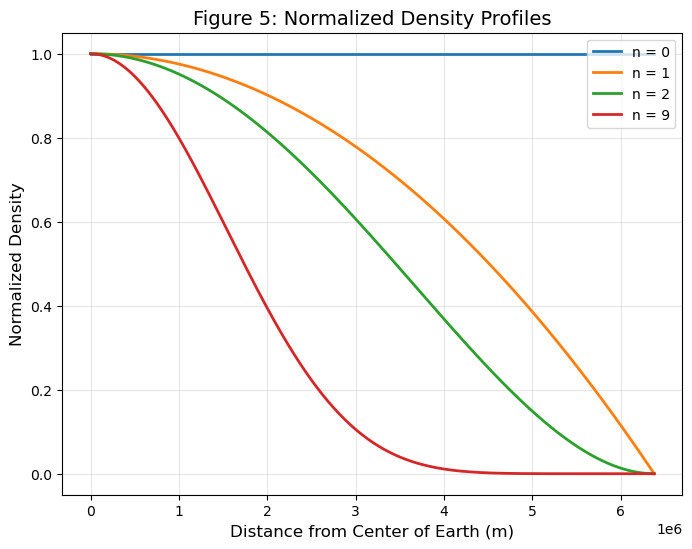

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad, solve_ivp

g0 = 9.81                   # m/s^2
R = 6378.1 * 1000           # meters
G = 6.6743e-11              # m^3 / (kg s^2)
M_earth = 5.972e24          # kg

n_values = [0, 1, 2, 9]

# Normalized density function
def normalized_density(r, n):
    return (1 - (r/R)**2)**n
    
def integrand_mass(r, n):
    return normalized_density(r, n) * (r**2)

rho_n_dict = {}
#print("Calculated Normalization Constants (rho_n):")
for n in n_values:
    integral_val, _ = quad(integrand_mass, 0, R, args=(n,))
    rho_n = M_earth / (4 * np.pi * integral_val)
    rho_n_dict[n] = rho_n
    
    #print(f"n = {n}: rho_n = {rho_n:.2f} kg/m^3 ({rho_n/1000:.2f} g/cm^3)")

fig5, ax5 = plt.subplots(figsize=(8, 6))
r_plot = np.linspace(0, R, 500)

for n in n_values:
    ax5.plot(r_plot, normalized_density(r_plot, n), linewidth=2, label=f'n = {n}')

ax5.set_title('Figure 5: Normalized Density Profiles', fontsize=14)
ax5.set_xlabel('Distance from Center of Earth (m)', fontsize=12)
ax5.set_ylabel(r'Normalized Density', fontsize=12)
ax5.legend(loc='upper right')
ax5.grid(True, alpha=0.3)
plt.show()

### Part 5, Section B (Forces)

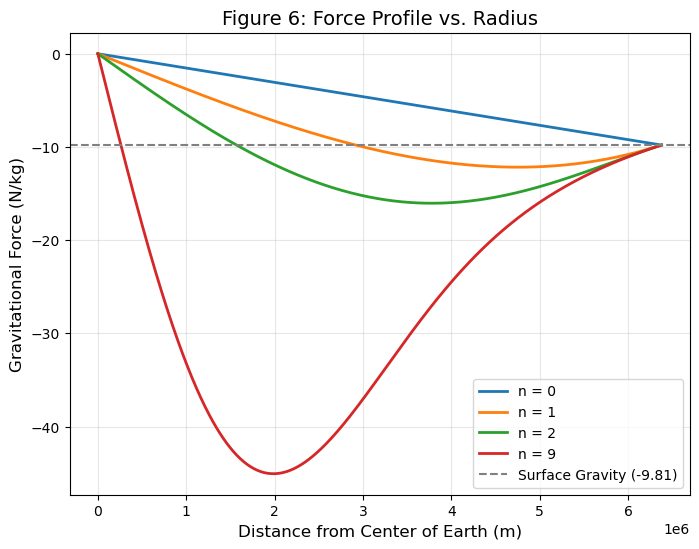

In [6]:
# the gravitational force at radius r inside the Earth
def calc_force(r, n, rho_n):
    if r == 0:
        return 0.0
    integral_val, _ = quad(integrand_mass, 0, r, args=(n,))
    M_enclosed = 4 * np.pi * rho_n * integral_val
    force = - (G * M_enclosed) / (r**2)
    return force

fig6, ax6 = plt.subplots(figsize=(8, 6))

for n in n_values:
    force_plot = [calc_force(r, n, rho_n_dict[n]) for r in r_plot]
    ax6.plot(r_plot, force_plot, linewidth=2, label=f'n = {n}')

ax6.set_title('Figure 6: Force Profile vs. Radius', fontsize=14)
ax6.set_xlabel('Distance from Center of Earth (m)', fontsize=12)
ax6.set_ylabel('Gravitational Force (N/kg)', fontsize=12)
ax6.axhline(-g0, color='gray', linestyle='--', label=f'Surface Gravity (-{g0})')
ax6.legend(loc='lower right')
ax6.grid(True, alpha=0.3)
plt.show()

### Part 5, Section C (Equations of Motion)

n = 0: Time to center = 1267.3 s ; Speed at center = 7905.3 m/s
n = 1: Time to center = 1096.5 s ; Speed at center = 10457.7 m/s
n = 2: Time to center = 1035.1 s ; Speed at center = 12182.9 m/s
n = 9: Time to center = 943.8 s ; Speed at center = 18370.7 m/s


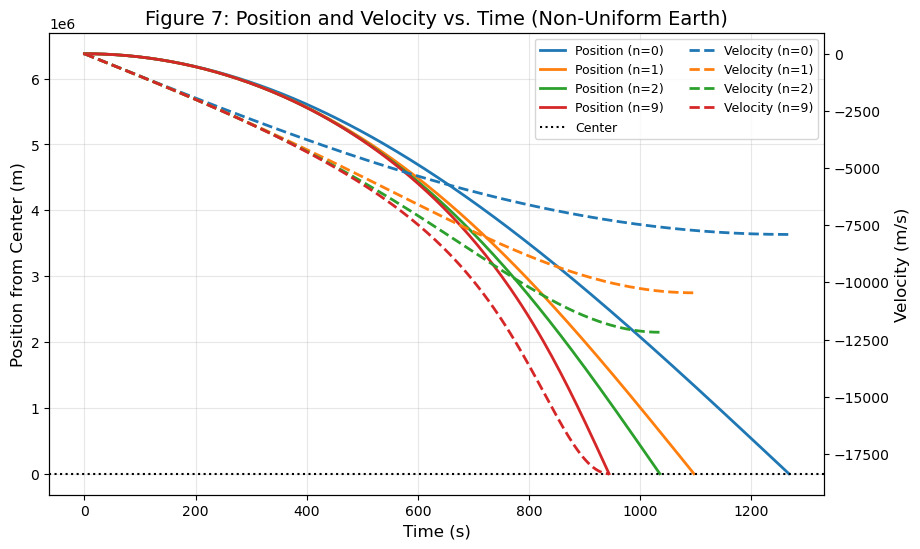

In [7]:
# ODE for non-uniform Earth
def motion_non_uniform(t, state, n, rho_n):
    y, vy = state
    r = np.abs(y)
    mag_F = np.abs(calc_force(r, n, rho_n))
    a = -mag_F * np.sign(y) if y != 0 else 0
    return [vy, a]

def reach_center(t, state, n, rho_n):
    return state[0]
reach_center.terminal = True
reach_center.direction = -1

# 2. Solve IVP and Plot Figure 7
fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

colors = {0: 'tab:blue', 1: 'tab:orange', 2: 'tab:green', 9: 'tab:red'}

for n in n_values:
    # Initial conditions: Drop from surface, 0 initial velocity
    state0 = [R, 0]
    sol = solve_ivp(
        motion_non_uniform,
        (0, 2000),
        state0,
        args=(n, rho_n_dict[n]),
        events=reach_center,
        max_step=5.0, 
        dense_output=True
    )
    
    t_center = sol.t_events[0][0]
    v_center = sol.y_events[0][0][1]
    print(f"n = {n}: Time to center = {t_center:.1f} s ; Speed at center = {abs(v_center):.1f} m/s")
    t_plot = sol.t
    y_plot = sol.y[0]
    v_plot = sol.y[1]
    ax1.plot(t_plot, y_plot, color=colors[n], linestyle='-', linewidth=2, label=f'Position (n={n})')
    ax2.plot(t_plot, v_plot, color=colors[n], linestyle='--', linewidth=2, label=f'Velocity (n={n})')

ax1.set_xlabel('Time (s)', fontsize=12)
ax1.set_ylabel('Position from Center (m)', fontsize=12)
ax2.set_ylabel('Velocity (m/s)', fontsize=12)
ax1.axhline(0, color='black', linestyle=':', label='Center')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9, ncol=2)
plt.title('Figure 7: Position and Velocity vs. Time (Non-Uniform Earth)', fontsize=14)
ax1.grid(True, alpha=0.3)
plt.show()

## Part 6: A Lunar Mine Shaft


Finally, with all of the framework in place, consider the case where the
the mine shaft is instead dug on the moon.

1. Compute the travel time to the center of the moon
                in case we dig a pole-to-pole mine shaft,
                so that we can again avoid the Coriolis force, though
                on the moon this force is very small. No drag force either,
   which is actually realistic for the moon!
3. What is the density (if you asssume a constant density) 
                of the moon compared to that of earth? 
4. How does the fall/orbit time depend on density? See if you can discover a 
        relationship between the density and the fall time. You should think beyond strictly linear 
        relationships.



This problem can actually be
done on paper, and then you can compare the answer with that for the homogenous earth
you did in Part 4.


In [8]:
g_moon = 1.625              # m/s^2 (Surface gravity)
R_moon = 1737.1 * 1000      # meters (Radius)
M_moon = 7.342e22           # kg (Mass)

vol_moon = (4/3) * np.pi * (R_moon**3)
rho_moon = M_moon / vol_moon

# constant density of the Earth (for comparison)
vol_earth = (4/3) * np.pi * (R**3)
rho_earth = M_earth / vol_earth

def motion_moon(t, state):
    y, vy = state
    # a = -g * (r/R)
    dvydt = -g_moon * (y / R_moon)
    return [vy, dvydt]

def reach_center_moon(t, state):
    return state[0]
reach_center_moon.terminal = True

sol_moon = solve_ivp(
    motion_moon,
    (0, 5000),
    [R_moon, 0],
    events=reach_center_moon
)

t_center_moon = sol_moon.t_events[0][0]

print(f"Moon vs Earth Comparison")
print(f"Moon Constant Density: {rho_moon:.2f} kg/m^3")
print(f"Earth Constant Density: {rho_earth:.2f} kg/m^3")
print(f"Density Ratio (Moon/Earth): {rho_moon/rho_earth:.4f}, meaning 0.6085 times the Earth density")
print(f"Time to reach Moon's center: {t_center_moon:.2f} s ({t_center_moon/60:.2f} min)")

Moon vs Earth Comparison
Moon Constant Density: 3343.88 kg/m^3
Earth Constant Density: 5494.87 kg/m^3
Density Ratio (Moon/Earth): 0.6085, meaning 0.6085 times the Earth density
Time to reach Moon's center: 1623.86 s (27.06 min)


**The Relationship between Density and Fall Time**


In Simple Harmonic Motion, the period is $T = 2\pi\sqrt{m/k}$. For a planet with constant density $\rho$, the gravitational acceleration at radius $r$ is:
$$g(r) = \frac{G M_{enc}}{r^2} = \left(\frac{4}{3}\pi G \rho\right)r$$

The "spring constant" $k$ per unit mass is $\frac{4}{3}\pi G \rho$. The time to reach the center ($t_{center}$) is one-quarter of the full oscillation period:
$$t_{center} = \frac{\pi}{2\sqrt{\frac{4}{3}\pi G \rho}} = \sqrt{\frac{3\pi}{16G\rho}}$$

So we get the fall time depends inversely on the square root of the density:
$$t \propto \frac{1}{\sqrt{\rho}}$$

**Note: Some of the steps aren't shown due to time constratints on writing down eqn syntax**

## Part 7: Fourier Transforming Orbits

Take the solutions for n=0 and n=9 of the orbits in Part 5 (the inhomogeneous earth) and Fourier Transform them, to see what frequencies (*1/periods*) are dominant in the power spectra. Comment on what you see.

**Hint:** you could take the orbit from the previous integration in Part 5c, but it is useful to increase the integration time and sampling to get more meaningful smooth enough curves. We discussed this in class.

For an example of a spectral analysis of galactic orbits see https://articles.adsabs.harvard.edu/pdf/1982ApJ...252..308B

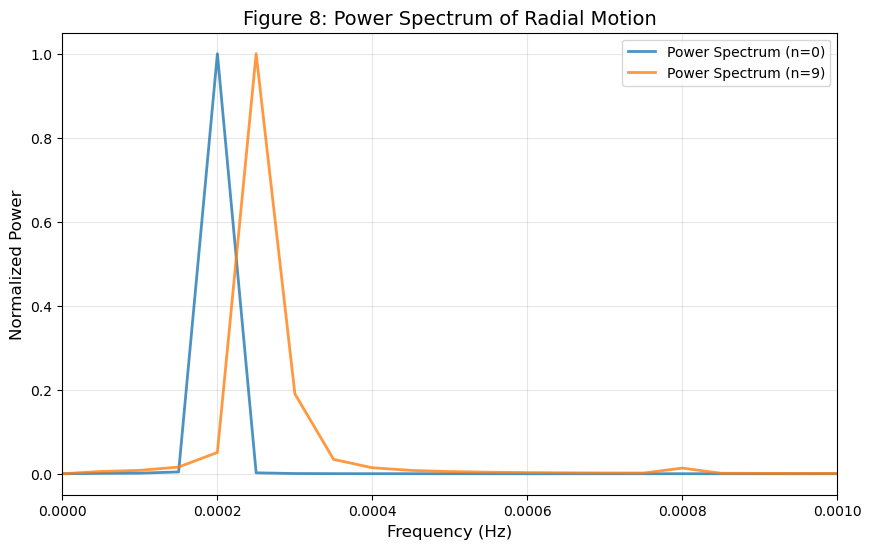

In [9]:
from scipy.fft import fft, fftfreq

# integration setup
t_final = 20000  
t_steps = 10000  
t_eval = np.linspace(0, t_final, t_steps)
dt = t_eval[1] - t_eval[0]

fig8, ax8 = plt.subplots(figsize=(10, 6))

for n in [0, 9]:
    rho_n = rho_n_dict[n]
    sol = solve_ivp(
        motion_non_uniform,
        (0, t_final),
        [R, 0],
        args=(n, rho_n),
        t_eval=t_eval,
        max_step=5.0
    )
    # Subtracting mean to remove DC component (0 frequency)
    y_signal = sol.y[0] - np.mean(sol.y[0])
    yf = fft(y_signal)
    xf = fftfreq(t_steps, dt)
    power = np.abs(yf[:t_steps//2])**2
    freqs = xf[:t_steps//2]
    
    # Normalizing
    power = power / np.max(power)
    
    ax8.plot(freqs, power, label=f'Power Spectrum (n={n})', alpha=0.8, linewidth=2)

# 3. Formatting the plot
ax8.set_title('Figure 8: Power Spectrum of Radial Motion', fontsize=14)
ax8.set_xlabel('Frequency (Hz)', fontsize=12)
ax8.set_ylabel('Normalized Power', fontsize=12)
ax8.set_xlim(0, 0.001) 
ax8.grid(True, alpha=0.3)
ax8.legend(loc = 'upper right')

plt.show()

Describe what we see here:

We see that for $ n = 0$, the the frequency that's dominant (0.2 mHz) is lower than for $n = 9$, which had a dominant frequency of around 0.3 mHz. We also see some bump in  the frequenzy sweep, telling us there's more than 1 frequency involved in $n=9$. 